### Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

# German Credit

In [8]:
# Cargar los datos desde el archivo CSV
data = pd.read_csv('GermanCredit.csv')

# Mostrar las primeras filas del dataset para inspección
print(data.head(n=2))

   Creditability  Account Balance  Duration of Credit (month)  \
0              1                1                          18   
1              1                1                           9   

   Payment Status of Previous Credit  Purpose  Credit Amount  \
0                                  4        2           1049   
1                                  4        0           2799   

   Value Savings/Stocks  Length of current employment  Instalment per cent  \
0                     1                             2                    4   
1                     1                             3                    2   

   Sex & Marital Status  ...  Duration in Current address  \
0                     2  ...                            4   
1                     3  ...                            2   

   Most valuable available asset  Age (years)  Concurrent Credits  \
0                              2           21                   3   
1                              1           36         

## Preparación de los datos

Definimos Creditability como nuestra variable objetivo (Y), y utilizamos las demás variables como predictores (X). Como Creditability ya está en forma binaria (1 o 0), no necesitamos realizar ninguna conversión.

In [11]:
from sklearn.preprocessing import StandardScaler
# Separar las variables independientes y la dependiente
X = data.drop(columns=['Creditability'])
y = data['Creditability']

# Dividir en conjuntos de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Entrenamiento del modelo

Ahora, entrenamos el modelo de regresión logística usando el conjunto de entrenamiento.

In [15]:
# Crear y ajustar el modelo
model = LogisticRegression(solver='liblinear', max_iter=2000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000, solver='liblinear')

## Predicciones

Utilizamos el modelo para predecir las probabilidades de que una persona devuelva el crédito en el conjunto de prueba.

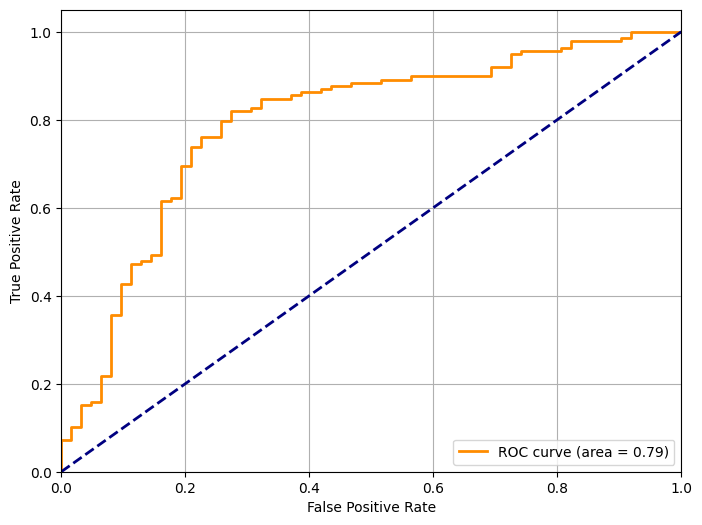

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

# Realizar predicciones
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Calcular la curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid()
plt.show()

## Matriz de confusión

Para calcular la matriz de confusión:

1. Umbral de Clasificación: Primero, debemos decidir un umbral para clasificar las probabilidades predichas. Por defecto, 0.5 se utiliza como umbral, lo que significa que si la probabilidad predicha es mayor o igual a 0.5, se clasifica como clase positiva (1), de lo contrario, como clase negativa (0).

2. Generar Predicciones Binarias: Convertimos las probabilidades predichas en predicciones de clase utilizando el umbral.

3. Calcular la Matriz de Confusión: Utilizamos confusion_matrix de sklearn para calcular la matriz de confusión.

La matriz de confusión se estructura de la siguiente manera:

- True Positives (TP): Correctamente predichos como positivos (C_1,1).
- True Negatives (TN): Correctamente predichos como negativos (C_0,0).
- False Positives (FP): Incorrectamente predichos como positivos (C_0,1).
- False Negatives (FN): Incorrectamente predichos como negativos (C_1,0).

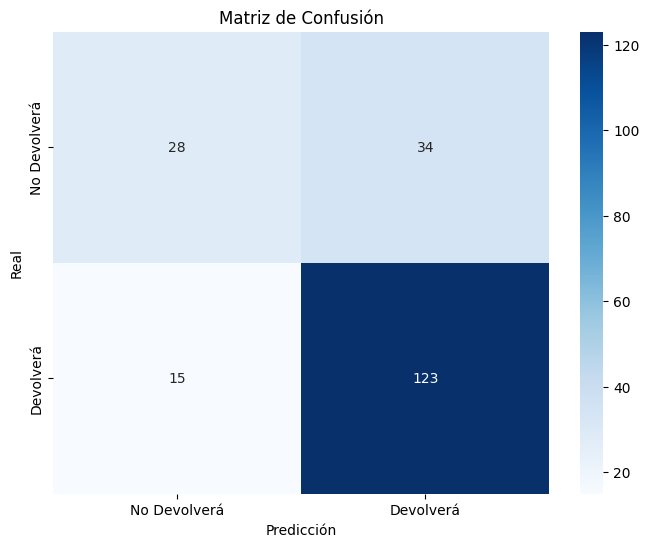

TN: 28, FP: 34, FN: 15, TP: 123


In [18]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Graficar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Devolverá', 'Devolverá'], 
            yticklabels=['No Devolverá', 'Devolverá'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

# Mostrar valores de TP, FP, TN, FN
tn, fp, fn, tp = cm.ravel()
print(f'TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}')